In [1]:
import numpy as np
data=np.load('data.npy')
target=np.load('target.npy')


In [2]:
train_data=data[:1000]
train_target=target[:1000]

test_data=data[1000:]
test_target=target[1000:]


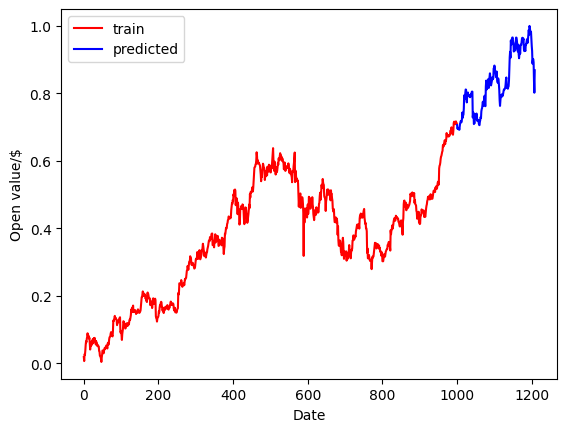

In [10]:
from matplotlib import pyplot as plt
test_x_range=np.arange(1000,len(data),1)

plt.plot(train_target,'r',label='train')
plt.plot(test_x_range,test_target,'b',label='test')

plt.xlabel('Date')
plt.ylabel('Open value/$')
plt.legend(['train','predicted'])
plt.show()

In [12]:
from keras.models import Sequential
from keras.layers import LSTM,Dense,Dropout

model=Sequential()

model.add(LSTM(units=96,return_sequences=True,input_shape=(data.shape[1],1)))
model.add(Dropout(0.2))

model.add(LSTM(units=96,return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(units=96,return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(units=96,return_sequences=False))
model.add(Dropout(0.2))

model.add(Dense(units=1,activation='linear'))

model.compile(optimizer='adam',loss='mean_squared_error')

In [26]:
history=model.fit(train_data,train_target,epochs=200,validation_split=0.1,batch_size=32)

Epoch 1/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 4.4779e-04 - val_loss: 6.3232e-04
Epoch 2/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 4.4122e-04 - val_loss: 2.2265e-04
Epoch 3/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 4.1666e-04 - val_loss: 1.0130e-04
Epoch 4/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 4.5687e-04 - val_loss: 0.0014
Epoch 5/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 4.5989e-04 - val_loss: 1.7060e-04
Epoch 6/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 3.9701e-04 - val_loss: 0.0011
Epoch 7/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 4.1538e-04 - val_loss: 3.1785e-04
Epoch 8/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 3.8635e-04 - val_loss: 2.8280e-04
Epoch 9/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 3.5139e-04 - val_loss: 6.2647e-04
Epoch 10/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 3.3151e-04 - val_loss: 1.4989e-04
Epoch 11/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 3.3446

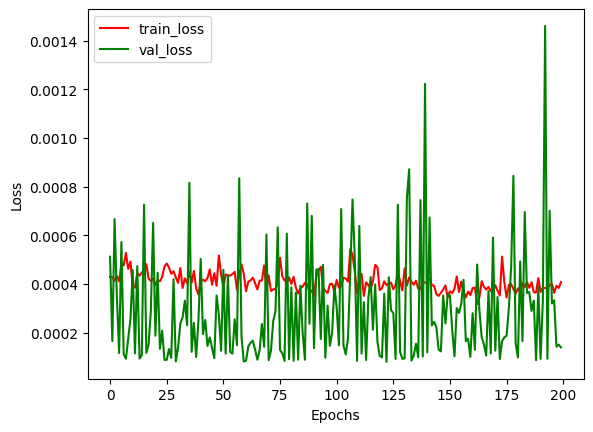

In [22]:
plt.plot(history.history['loss'],'r',label='train_loss')
plt.plot(history.history['val_loss'],'g',label='val_loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [23]:
result=model.predict(test_data)
from sklearn.metrics import r2_score
r2=r2_score(test_target,result)
print('R2 score is :',r2)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
R2 score is : 0.7459298105170683


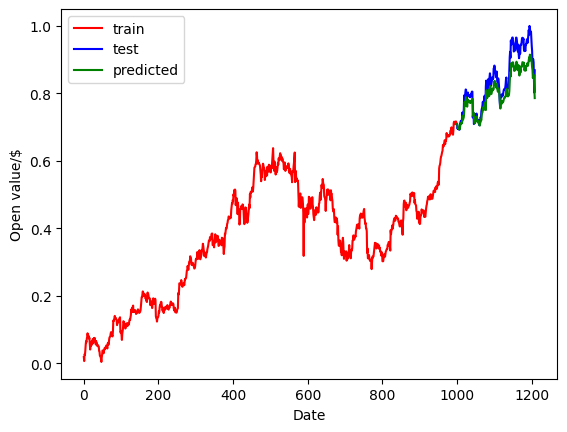

In [24]:
test_x_range=np.arange(1000,len(data),1)
plt.plot(train_target,'r',label='train')
plt.plot(test_x_range,test_target,'b',label='test')
plt.plot(test_x_range,result,'g',label='predicted')
plt.xlabel('Date')
plt.ylabel('Open value/$')
plt.legend()
plt.show()


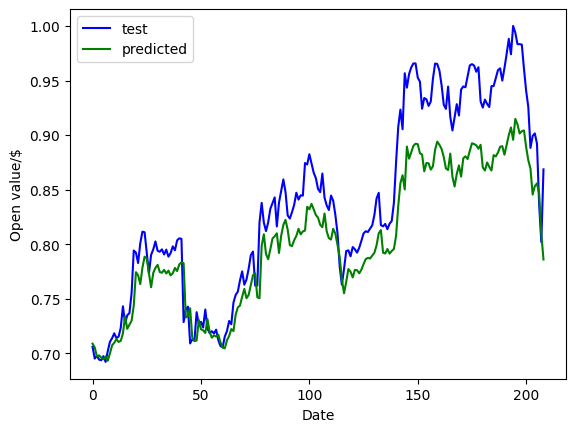

In [25]:
plt.plot(test_target,'b',label='test')
plt.plot(result,'g',label='predicted')
plt.xlabel('Date')
plt.ylabel('Open value/$')
plt.legend()
plt.show()